In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN, SAC, TD3
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import EvalCallback


In [8]:
TOTAL_TIMESTEPS = 100_000
LOG_DIR_BASE = "./logs"

def make_env(env_id, log_dir):
    env = gym.make(env_id)
    env = Monitor(env, log_dir)  # needed to log episode rewards to disk
    return env

In [3]:
def train(algo_name, algo_cls, env_id, timesteps=TOTAL_TIMESTEPS):
    log_dir = f"{LOG_DIR_BASE}/{algo_name}_{env_id}"
    import os
    os.makedirs(log_dir, exist_ok=True)

    env = make_env(env_id, log_dir)

    # eval env for periodic evaluation (optional but useful)
    eval_env = make_env(env_id, log_dir + "_eval")
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=log_dir,
        log_path=log_dir,
        eval_freq=2000,
        n_eval_episodes=5,
        deterministic=True,
    )

    model = algo_cls("MlpPolicy", env, verbose=0)
    model.learn(total_timesteps=timesteps, callback=eval_callback)
    model.save(f"{log_dir}/final_model")

    return log_dir


In [4]:
def plot_reward_curve(log_dir, label):
    x, y = ts2xy(load_results(log_dir), "timesteps")
    plt.plot(x, y, label=label)


Training DQN on CartPole-v1 ...
Eval num_timesteps=2000, episode_reward=11.20 +/- 1.47
Episode length: 11.20 +/- 1.47
New best mean reward!
Eval num_timesteps=4000, episode_reward=10.00 +/- 1.55
Episode length: 10.00 +/- 1.55
Eval num_timesteps=6000, episode_reward=9.40 +/- 0.49
Episode length: 9.40 +/- 0.49
Eval num_timesteps=8000, episode_reward=9.80 +/- 0.40
Episode length: 9.80 +/- 0.40
Eval num_timesteps=10000, episode_reward=8.60 +/- 0.49
Episode length: 8.60 +/- 0.49
Eval num_timesteps=12000, episode_reward=8.60 +/- 0.49
Episode length: 8.60 +/- 0.49
Eval num_timesteps=14000, episode_reward=8.80 +/- 0.75
Episode length: 8.80 +/- 0.75
Eval num_timesteps=16000, episode_reward=9.40 +/- 0.80
Episode length: 9.40 +/- 0.80
Eval num_timesteps=18000, episode_reward=9.40 +/- 0.49
Episode length: 9.40 +/- 0.49
Eval num_timesteps=20000, episode_reward=9.00 +/- 0.63
Episode length: 9.00 +/- 0.63
Eval num_timesteps=22000, episode_reward=9.00 +/- 0.63
Episode length: 9.00 +/- 0.63
Eval num_ti

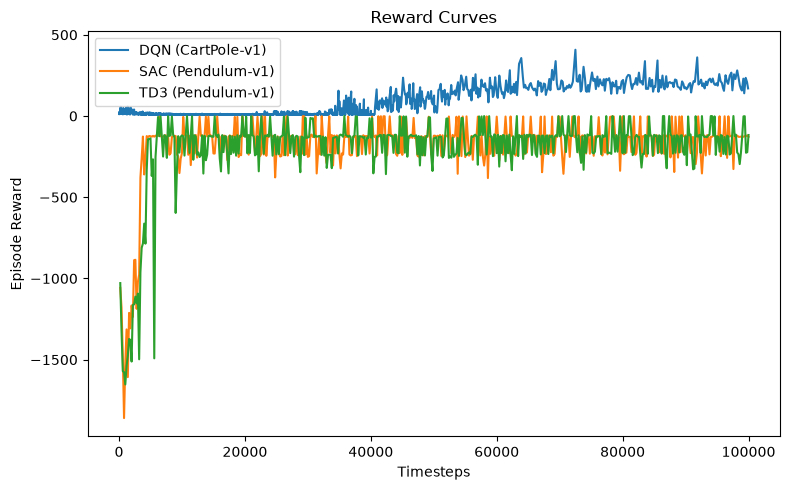

In [5]:

    runs = [
        ("DQN", DQN, "CartPole-v1"),
        ("SAC", SAC, "Pendulum-v1"),
        ("TD3", TD3, "Pendulum-v1"),
    ]
    

    log_dirs = []
    for name, cls, env_id in runs:
        print(f"Training {name} on {env_id} ...")
        log_dir = train(name, cls, env_id)
        log_dirs.append((log_dir, f"{name} ({env_id})"))

    plt.figure(figsize=(8, 5))
    for log_dir, label in log_dirs:
        plot_reward_curve(log_dir, label)
    plt.xlabel("Timesteps")
    plt.ylabel("Episode Reward")
    plt.title("Reward Curves")
    plt.legend()
    plt.tight_layout()
    plt.savefig("reward_curves.png")
    plt.show()

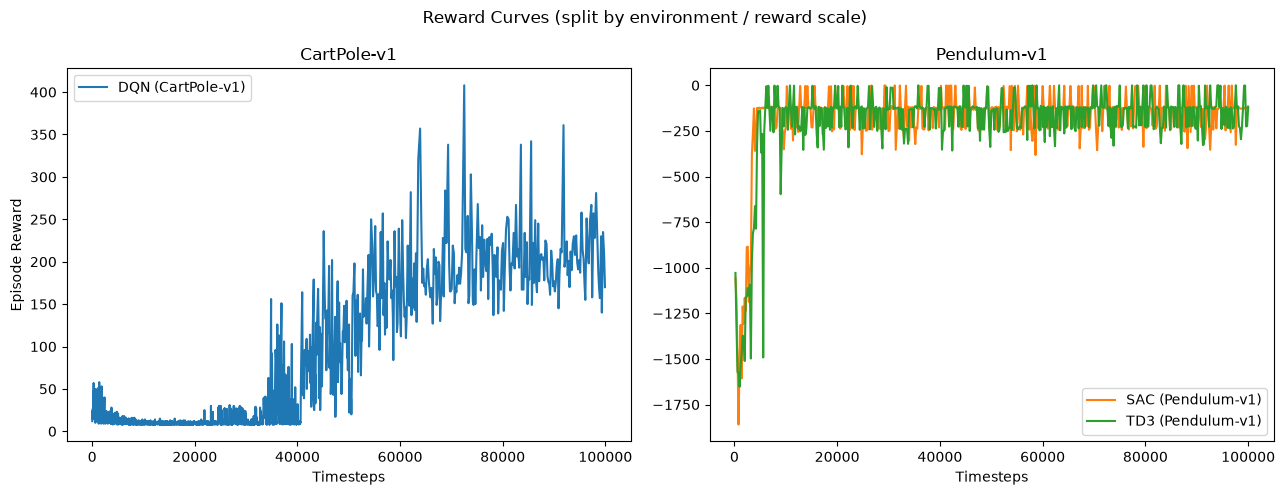

In [6]:
import matplotlib.pyplot as plt
from stable_baselines3.common.results_plotter import load_results, ts2xy
 
LOG_DIR_BASE = "./logs"
 
runs = [
    ("DQN", "CartPole-v1"),
    ("SAC", "Pendulum-v1"),
    ("TD3", "Pendulum-v1"),
]
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# --- Subplot 1: DQN / CartPole ---
name, env_id = runs[0]
log_dir = f"{LOG_DIR_BASE}/{name}_{env_id}"
x, y = ts2xy(load_results(log_dir), "timesteps")
axes[0].plot(x, y, label=f"{name} ({env_id})", color="tab:blue")
axes[0].set_title("CartPole-v1")
axes[0].set_xlabel("Timesteps")
axes[0].set_ylabel("Episode Reward")
axes[0].legend()
 
# --- Subplot 2: SAC vs TD3 / Pendulum ---
colors = {"SAC": "tab:orange", "TD3": "tab:green"}
for name, env_id in runs[1:]:
    log_dir = f"{LOG_DIR_BASE}/{name}_{env_id}"
    x, y = ts2xy(load_results(log_dir), "timesteps")
    axes[1].plot(x, y, label=f"{name} ({env_id})", color=colors[name])
axes[1].set_title("Pendulum-v1")
axes[1].set_xlabel("Timesteps")
axes[1].legend()
 
fig.suptitle("Reward Curves (split by environment / reward scale)")
plt.tight_layout()
plt.savefig("reward_curves_split.png", dpi=150)
plt.show()

## 1. Trainierte Modelle laden

Wir laden die bereits trainierten `final_model`-Checkpoints aus den `./logs`-Ordnern.
Alternativ könnte man auch die von `EvalCallback` gespeicherten `best_model.zip` laden, wenn man das *beste* statt das *letzte* Modell analysieren möchte.

In [1]:
from stable_baselines3 import DQN, SAC, TD3

LOG_DIR_BASE = "./logs"

def load_model(algo_name, algo_cls, env_id):
    log_dir = f"{LOG_DIR_BASE}/{algo_name}_{env_id}"
    model = algo_cls.load(f"{log_dir}/final_model")
    return model

dqn_model = load_model("DQN", DQN, "CartPole-v1")
sac_model = load_model("SAC", SAC, "Pendulum-v1")
td3_model = load_model("TD3", TD3, "Pendulum-v1")


## 2. Q-Werte extrahieren

Die Extraktion unterscheidet sich je nach Aktionsraum:

- **DQN (diskret, CartPole):** Das Q-Netzwerk gibt für einen Zustand direkt einen Q-Wert *pro Aktion* aus (`model.q_net`). Man braucht also keine Aktion als Eingabe.
- **SAC / TD3 (kontinuierlich, Pendulum):** Hier ist Q eine Funktion von *Zustand UND Aktion* (`model.critic`). Beide Algorithmen nutzen zusätzlich **Twin-Critics** (zwei unabhängige Q-Netze), um Overestimation-Bias zu reduzieren — deshalb bekommt man bei jedem Aufruf zwei Q-Schätzungen zurück.

In [ ]:
import torch as th
import numpy as np

@th.no_grad()
def get_q_values_dqn(model: DQN, obs: np.ndarray) -> np.ndarray:
    """Gibt Q(s, a) für ALLE diskreten Aktionen zurueck. obs: (n_samples, obs_dim)"""
    obs_tensor, _ = model.policy.obs_to_tensor(obs)
    q_values = model.q_net(obs_tensor)          # shape: (n_samples, n_actions)
    return q_values.cpu().numpy()


@th.no_grad()
def get_q_values_continuous(model, obs: np.ndarray, actions: np.ndarray) -> np.ndarray:
    """Gibt Q(s, a) fuer SAC/TD3 zurueck -> Array shape (n_critics, n_samples).
    Beide Algorithmen nutzen Twin-Critics, daher i.d.R. 2 Werte pro (s,a)-Paar."""
    obs_tensor, _ = model.policy.obs_to_tensor(obs)
    actions_tensor = th.as_tensor(actions, dtype=th.float32, device=model.device)
    q_values = model.critic(obs_tensor, actions_tensor)   # Tuple(q1, q2, ...)
    return np.stack([q.cpu().numpy().flatten() for q in q_values])


test_env_dqn = gym.make("CartPole-v1")
obs_dqn, _ = test_env_dqn.reset()
print("DQN Q(s, .) fuer alle Aktionen:", get_q_values_dqn(dqn_model, obs_dqn[np.newaxis, :]))

test_env_sac = gym.make("Pendulum-v1")
obs_sac, _ = test_env_sac.reset()
action_sac, _ = sac_model.predict(obs_sac, deterministic=True)
print("SAC Twin-Q(s,a):", get_q_values_continuous(sac_model, obs_sac[np.newaxis, :], action_sac[np.newaxis, :]))


DQN Q(s, .) fuer alle Aktionen: [[9.899642 9.889513]]
SAC Twin-Q(s,a): [[-197.38509]
 [-199.09933]]


## 3. Ground Truth: Monte-Carlo-Return als Vergleichsbasis

Die eigentliche Forschungsfrage ("Wie stark weichen gelernte Q-Funktionen von der theoretischen Optimalität ab?") lässt sich nicht beantworten, indem man sich nur die Q-Werte selbst ansieht — man braucht eine **unabhängige Schätzung des "wahren" Werts**, um Bias zu messen.

Standardmethode (siehe TD3-Paper, Fujimoto et al. 2018): Für eine Reihe von Startzuständen wird
1. der vom Netz **geschätzte** Q-Wert `Q(s₀, a₀)` notiert, und
2. eine komplette Episode **deterministisch** ab `s₀` ausgeführt und der **tatsächliche diskontierte Return** aufsummiert (Monte-Carlo-Schätzung des wahren Werts).

Die Differenz `Q_geschätzt − Return_MC` ist der **Overestimation-Bias**.

In [11]:
def rollout_discounted_return(model, env, gamma, deterministic=True, max_steps=1000):
    """Fuehrt eine Episode aus und gibt (start_obs, start_action, diskontierter_return) zurueck."""
    obs, _ = env.reset()
    start_obs = obs.copy()
    start_action, _ = model.predict(obs, deterministic=deterministic)

    G, discount, steps = 0.0, 1.0, 0
    done = False
    while not done and steps < max_steps:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, _ = env.step(action)
        G += discount * reward
        discount *= gamma
        done = terminated or truncated
        steps += 1

    return start_obs, start_action, G


def estimate_q_bias(model, env, get_q_fn, n_episodes=50, is_discrete=False):
    """Vergleicht geschaetzten Q-Wert am Episodenstart mit dem Monte-Carlo-Return."""
    gamma = model.gamma
    q_preds, mc_returns = [], []

    for _ in range(n_episodes):
        s0, a0, G = rollout_discounted_return(model, env, gamma)

        if is_discrete:
            q_all = get_q_fn(model, s0[np.newaxis, :])       # (1, n_actions)
            q_pred = q_all[0, int(a0)]
        else:
            q_vals = get_q_fn(model, s0[np.newaxis, :], a0[np.newaxis, :])  # (n_critics, 1)
            q_pred = q_vals.min(axis=0)[0]   # SB3 nutzt beim Training i.d.R. auch das Minimum der Twin-Critics

        q_preds.append(q_pred)
        mc_returns.append(G)

    q_preds, mc_returns = np.array(q_preds), np.array(mc_returns)
    bias = q_preds - mc_returns
    return q_preds, mc_returns, bias


# Eval-Envs (nicht die Monitor-Trainings-Envs verwenden!)
dqn_eval_env = gym.make("CartPole-v1")
sac_eval_env = gym.make("Pendulum-v1")
td3_eval_env = gym.make("Pendulum-v1")

q_dqn, mc_dqn, bias_dqn = estimate_q_bias(dqn_model, dqn_eval_env, get_q_values_dqn, is_discrete=True)
q_sac, mc_sac, bias_sac = estimate_q_bias(sac_model, sac_eval_env, get_q_values_continuous, is_discrete=False)
q_td3, mc_td3, bias_td3 = estimate_q_bias(td3_model, td3_eval_env, get_q_values_continuous, is_discrete=False)

for name, bias in [("DQN", bias_dqn), ("SAC", bias_sac), ("TD3", bias_td3)]:
    print(f"{name}: mean bias = {bias.mean():.3f}  (+ = Overestimation, - = Underestimation), std = {bias.std():.3f}")


DQN: mean bias = -76.707  (+ = Overestimation, - = Underestimation), std = 4.443
SAC: mean bias = 0.240  (+ = Overestimation, - = Underestimation), std = 26.079
TD3: mean bias = -6.766  (+ = Overestimation, - = Underestimation), std = 21.284


## 4. Visualisierung: geschätzt vs. tatsächlich

Ein Scatterplot `Q_geschätzt` gegen `Return_MC` (mit der Diagonalen als Referenz "perfekte Schätzung") macht Über-/Unterschätzung sofort sichtbar.

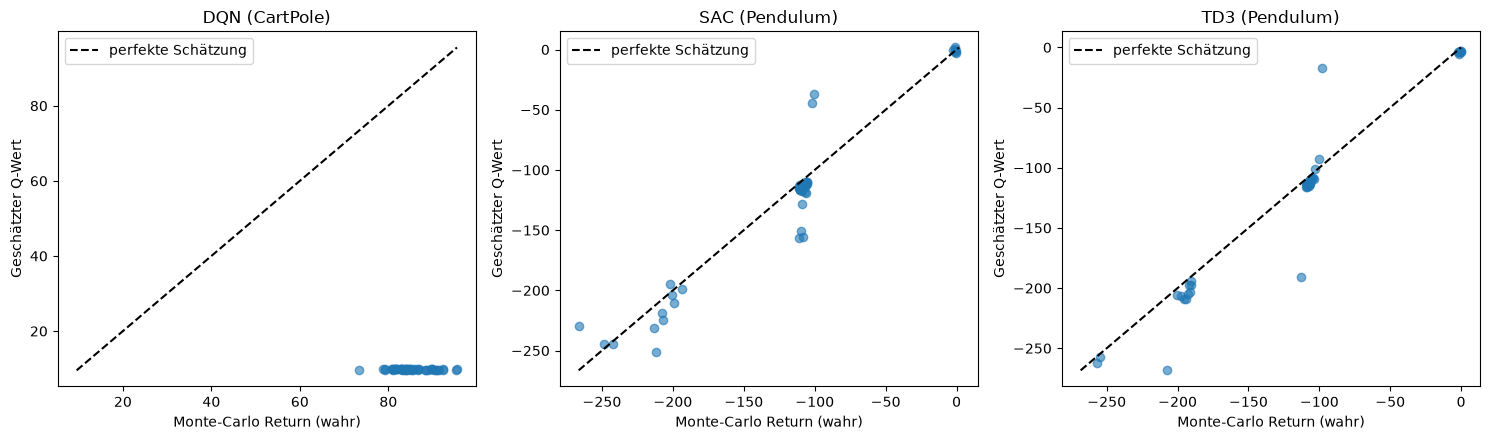

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, name, q_pred, mc in zip(
    axes, ["DQN (CartPole)", "SAC (Pendulum)", "TD3 (Pendulum)"],
    [q_dqn, q_sac, q_td3], [mc_dqn, mc_sac, mc_td3]
):
    lo, hi = min(q_pred.min(), mc.min()), max(q_pred.max(), mc.max())
    ax.scatter(mc, q_pred, alpha=0.6)
    ax.plot([lo, hi], [lo, hi], "k--", label="perfekte Schätzung")
    ax.set_xlabel("Monte-Carlo Return (wahr)")
    ax.set_ylabel("Geschätzter Q-Wert")
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.savefig("q_value_bias.png", dpi=150)
plt.show()


## 5. Langzeitverhalten: Q-Funktion über den Trainingsverlauf

Aktuell existiert nur das *finale* Modell — für die Frage "Was repräsentiert eine Q-Funktion nach langer Trainingszeit, und wie entwickelt sich der Bias über die Zeit?" braucht man **Checkpoints während des Trainings**.

Dazu `train()` um einen `CheckpointCallback` erweitern (z. B. alle 10.000 Timesteps ein Modell speichern), danach kann man `estimate_q_bias()` für jeden Checkpoint erneut ausführen und den Bias über die Timesteps plotten.

In [9]:
from stable_baselines3.common.callbacks import CheckpointCallback, CallbackList

def train_with_checkpoints(algo_name, algo_cls, env_id, timesteps=TOTAL_TIMESTEPS, save_freq=10_000):
    log_dir = f"{LOG_DIR_BASE}/{algo_name}_{env_id}"
    import os
    os.makedirs(log_dir, exist_ok=True)

    env = make_env(env_id, log_dir)
    eval_env = make_env(env_id, log_dir + "_eval")

    eval_callback = EvalCallback(
        eval_env, best_model_save_path=log_dir, log_path=log_dir,
        eval_freq=2000, n_eval_episodes=5, deterministic=True,
    )
    checkpoint_callback = CheckpointCallback(
        save_freq=save_freq, save_path=f"{log_dir}/checkpoints",
        name_prefix="model",
    )

    model = algo_cls("MlpPolicy", env, verbose=0)
    model.learn(total_timesteps=timesteps, callback=CallbackList([eval_callback, checkpoint_callback]))
    model.save(f"{log_dir}/final_model")
    return log_dir

# Beispiel-Aufruf zum erneuten Trainieren mit Checkpoints (auskommentiert, da rechenintensiv):
# train_with_checkpoints("DQN", DQN, "CartPole-v1")
